In [23]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel,Field
from typing import List,Annotated
import operator

load_dotenv()
import os


In [24]:
llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview",api_key=os.getenv('GEMINI_API_KEY'))

In [25]:
class QuadState(TypedDict):
    a : int
    b : int
    c : int

    equation : str
    dis :  float
    res : str

In [26]:
def se(state:QuadState):
    eq = f"{state['a']}x2+{state['b']}x+{state['c']}"

    return {'equation':eq}

def cd(state:QuadState):
    dis = state['b']**2 - (4*state['a']*state['c'])

    return {'dis':dis}

def rr(state:QuadState):
    r1 = (-state['b'] + state['dis'] **5)/2*state['a']
    r2 = (-state['b'] - state['dis'] **5)/2*state['a']

    res = f"the root are {r1} & {r2}"

    return {'res':res}


def repr(state:QuadState):
    r = (-state['b']/2*state['a'])

    res = f"repeating root is {r}"
    return {'res':res}

def nr(state:QuadState):
    return {'res':'no real root'}


def check_condition(state:QuadState):
    dis = state['dis']

    if dis > 0:
        return 'rr'
    elif dis == 0:
        return 'repr'
    else:
        return 'nr'


In [33]:
graph = StateGraph(QuadState)
graph.add_node('se',se)
graph.add_node('cd',cd)
graph.add_node('rr',rr)
graph.add_node('repr',repr)
graph.add_node('nr',nr)
# graph.add_node('check_condition',check_condition)

graph.add_edge(START,'se')
graph.add_edge('se','cd')

graph.add_conditional_edges(
    'cd',
    check_condition,
    {
        'rr': 'rr',
        'repr': 'repr',
        'nr': 'nr'
    }
)
graph.add_edge('rr',END)
graph.add_edge('repr',END)
graph.add_edge('nr',END)

work = graph.compile()

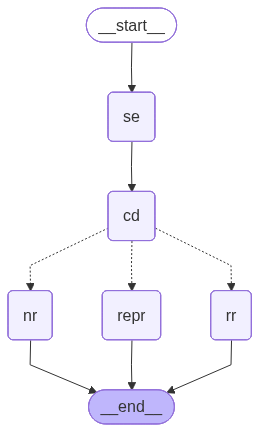

In [34]:
work

In [40]:
work.invoke({'a':6,'b':9,'c':1})

{'a': 6,
 'b': 9,
 'c': 1,
 'equation': '6x2+9x+1',
 'dis': 57,
 'res': 'the root are 1805076144.0 & -1805076198.0'}